In [ ]:
import pandas as pd

# loading the data
df = pd.read_csv('../IMDB Dataset.csv')

In [2]:
import re

def clean_review(text):
    # converting to lowercase
    text = text.lower()
    
    # replacing HTML br tags with a space
    text = re.sub(r'<br\s*/?>', ' ', text)
    
    # removing any other HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # replacing multiple spaces with single space
    text = re.sub(r'\s+', ' ', text)
    
    # striping leading/trailing spaces
    text = text.strip()
    
    return text

# creating a new cleaned column
df['cleaned_review'] = df['review'].apply(clean_review)

# Check the result
print("Original vs Cleaned:")
print("ORIGINAL:", df['review'][0][:200] + "...")
print("\nCLEANED:", df['cleaned_review'][0][:200] + "...")

Original vs Cleaned:
ORIGINAL: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...

CLEANED: one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me. the first thing that struck me about oz was i...


In [4]:
pip install tensorflow

     -------------------------------------- 350.6/350.6 MB 1.4 MB/s eta 0:00:00
     -------------------------------------- 210.7/210.7 kB 2.1 MB/s eta 0:00:00
     -------------------------------------- 135.8/135.8 kB 3.9 MB/s eta 0:00:00
     ---------------------------------------- 71.9/71.9 kB 4.1 MB/s eta 0:00:00
     ---------------------------------------- 60.3/60.3 kB 3.1 MB/s eta 0:00:00
     ---------------------------------------- 26.4/26.4 MB 1.6 MB/s eta 0:00:00
     ---------------------------------------- 1.5/1.5 MB 1.8 MB/s eta 0:00:00
     ---------------------------------------- 4.8/4.8 MB 1.4 MB/s eta 0:00:00
     ---------------------------------------- 2.9/2.9 MB 2.5 MB/s eta 0:00:00
     ---------------------------------------- 64.7/64.7 kB ? eta 0:00:00
     -------------------------------------- 437.9/437.9 kB 2.5 MB/s eta 0:00:00
     ---------------------------------------- 57.5/57.5 kB 3.1 MB/s eta 0:00:00
     -------------------------------------- 321.8/321

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# parameters
max_words = 10000   # vocabulary size
max_len = 200       # max review length

# tokenize
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['cleaned_review'])

# convert text to sequences
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])

# pad sequences
X = pad_sequences(sequences, maxlen=max_len)

# labels
y = df['sentiment'].map({'negative': 0, 'positive': 1}).values

print("Shape of X:", X.shape)

Shape of X: (50000, 200)


In [6]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

In [7]:
import torch

X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)

X_val_tensor = torch.LongTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val).reshape(-1, 1)

X_test_tensor = torch.LongTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

In [8]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [9]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128):
        super(LSTMModel, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        x = hidden[-1]
        x = self.fc(x)
        return self.sigmoid(x)

In [10]:
vocab_size = max_words

model = LSTMModel(vocab_size)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [11]:
# training loop
num_epochs = 50
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # training phase
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for batch_X, batch_y in train_loader:
        # forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        # calculating the accuracy
        predicted = (outputs >= 0.5).float()
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()
    
    # validation phase
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            
            predicted = (outputs >= 0.5).float() # this is the threshold rule
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()
    
    # recording the losses and the accuracies
    train_losses.append(train_loss/len(train_loader))
    val_losses.append(val_loss/len(val_loader))
    train_accuracies.append(100 * train_correct / train_total)
    val_accuracies.append(100 * val_correct / val_total)
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, 'f'Train Acc: {train_accuracies[-1]:.2f}%, Val Acc: {val_accuracies[-1]:.2f}%')

Epoch [10/50], Train Loss: 0.0940, Train Acc: 96.72%, Val Acc: 86.68%
Epoch [20/50], Train Loss: 0.0139, Train Acc: 99.61%, Val Acc: 86.65%
Epoch [30/50], Train Loss: 0.0001, Train Acc: 100.00%, Val Acc: 87.61%
Epoch [40/50], Train Loss: 0.0100, Train Acc: 99.83%, Val Acc: 83.47%
Epoch [50/50], Train Loss: 0.0001, Train Acc: 100.00%, Val Acc: 87.68%


In [12]:
# let's evaluate on the TEST set
model.eval()
with torch.no_grad():
    # getting predictions on test set
    test_outputs = model(X_test_tensor)
    test_predictions = (test_outputs >= 0.5).float()
    
    # calculating test accuracy
    test_accuracy = (test_predictions == y_test_tensor).float().mean()
    print(f"Test Accuracy: {test_accuracy:.2%}")
    
    # getting predictions for confusion matrix
    y_true = y_test_tensor.numpy()
    y_pred = test_predictions.numpy()

Test Accuracy: 87.86%


 Model saved to ../model/lstm_model.pth


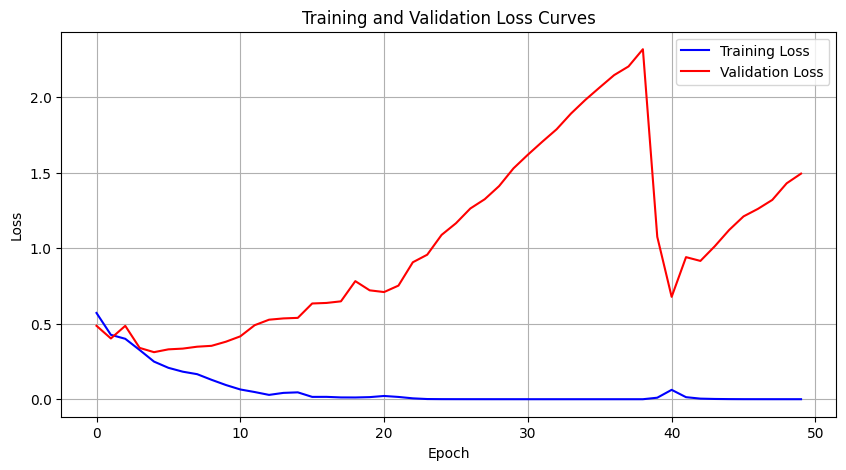

 Loss curves saved to ../results/lstm_model/loss_curves.png


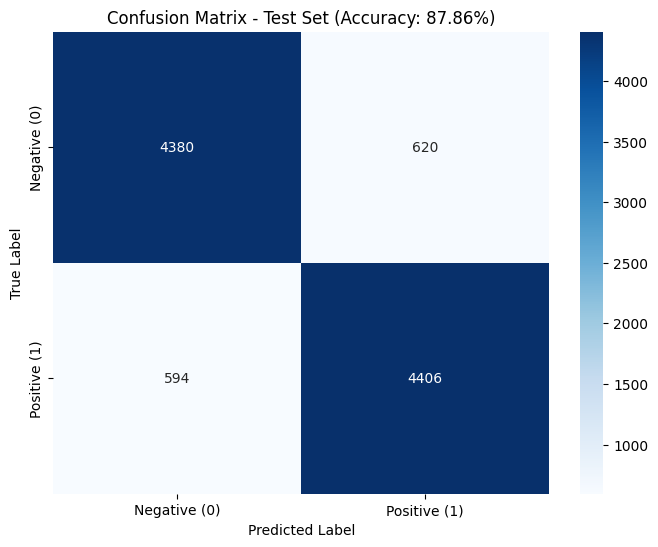

 Confusion matrix saved to ../results/lstm_model/confusion_matrix.png
 Metrics saved to ../results/lstm_model/metrics.txt
 Results discussion saved to ../results/lstm_model/results_discussion.txt

 ALL DONE! LSTM Model saved correctly!


In [14]:
# this step is for saving everything
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import torch

# create folder if not exists
os.makedirs('../results/lstm_model', exist_ok=True)

# saving the model
torch.save(model.state_dict(), '../model/lstm_model.pth')
print(" Model saved to ../model/lstm_model.pth")

# plotting and saving loss curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True)
plt.savefig('../results/lstm_model/loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Loss curves saved to ../results/lstm_model/loss_curves.png")

# creating and saving confusion matrix at root level
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative (0)', 'Positive (1)'], yticklabels=['Negative (0)', 'Positive (1)'])
plt.title(f'Confusion Matrix - Test Set (Accuracy: {test_accuracy:.2%})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('../results/lstm_model/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Confusion matrix saved to ../results/lstm_model/confusion_matrix.png")

# saving metrics
with open('../results/lstm_model/metrics.txt', 'w') as f:
    f.write("="*50 + "\n")
    f.write("LSTM Model - EVALUATION METRICS\n")
    f.write("="*50 + "\n\n")
    
    f.write(f"Test Set Accuracy: {test_accuracy:.2%}\n\n")
    
    f.write("Classification Report:\n")
    f.write("-"*30 + "\n")
    f.write(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))
    
    f.write("\n\nConfusion Matrix:\n")
    f.write("-"*30 + "\n")
    f.write(f"True Negatives: {cm[0,0]}\n")
    f.write(f"False Positives: {cm[0,1]}\n")
    f.write(f"False Negatives: {cm[1,0]}\n")
    f.write(f"True Positives: {cm[1,1]}\n")

print(" Metrics saved to ../results/lstm_model/metrics.txt")

# results discussion
with open('../results/lstm_model/results_discussion.txt', 'w') as f:
    f.write("="*50 + "\n")
    f.write("LSTM Model - RESULTS DISCUSSION\n")
    f.write("="*50 + "\n\n")
    
    f.write(f"Model Performance:\n")
    f.write(f"- Test Accuracy: {test_accuracy:.2%}\n")
    f.write(f"- Training Accuracy (final): {train_accuracies[-1]:.2f}%\n")
    f.write(f"- Validation Accuracy (final): {val_accuracies[-1]:.2f}%\n\n")

print(" Results discussion saved to ../results/lstm_model/results_discussion.txt")

print("\n" + "="*50)
print(" ALL DONE! LSTM Model saved correctly!")
print("="*50)